# 1. Introduction and market context

### 1.1 The telecommunications market in Colombia

Colombia is one of the most active mobile telecommunications markets in Latin America. In 2024, the sector reached an approximate value of USD 7,390 millions, with a growth projection of up to USD 8.4 billion in 2034 (1.4% CAGR) [1]. The market is dominated by three main operators: Claro (65% market share), Tigo (23%) and Movistar (6%), with operators virtuals like Virgin Mobile and WOM capturing young and digital segments [2]. The sector is going through a profound transformation driven by three forces simultaneous: the deployment of 5G networks (with more than 2 million customers under that technology at the end of 2024) [3], the expansion of fiber optics until household (FTTH), and increasing pressure on ARPU (average income per user) — prepaid recharges fell between 5% and 7% year-on-year at the beginning from 2025, in a context of inflation of 5% and GDP growth of barely 2.5%-2.8% [4].
### 1.2 Churn dynamics in Colombia
In mature and competitive markets like Colombia, retain a customer existing is between 5 and 25 times cheaper than purchasing a new one [5]. The number portability — the mechanism regulated by the CRC that allows changing operator retaining the number — has established itself as the main one competition thermometer. In the first half of 2025, they registered 3.34 million shipments, although with a decrease of 5.4% compared to to the same period in 2024 [6]. A critical fact for this analysis: in the first quarter of 2025, the portability represented only 15.8% of the total lines removed from the market [6]. This means that 84.2% of the remaining churn is natural not associated with portation — cancellations due to non-payment, abandonments without migration to another operator, or plan changes within the same provider. This distinction it matters because the churn for portability (voluntary and competitive) and the churn non-payment (involuntary) requires different interventions. A model predictive can anticipate disengagement signals preceding both types, but the most effective lever of action points to the voluntary churn — where a specific value offer can change the customer's decision.
### 1.3 Opportunity:
behavioral cues precede churn Colombian operators already use advanced analytics to anticipate attrition behaviors [7]. The evidence in the sector shows that signs such as decreasing service usage, device aging, and the low monthly use/charge ratio precedes churn by weeks or months — sufficient window to intervene proactively. This analysis starts from that premise and applies it to a specific segment: high-value customers with aging devices, where intervention more cost-effective is not a discount, but a device upgrade financed in installments that resolves the churn driver and creates retention structural simultaneously.

### **References**
[1] Expert Market Research / ICEX Spain. *The telecommunications market in Colombia 2025*. October 2025. [2] Deloitte Colombia. *The telecommunications industry in Colombia*. 2023. [3] TeleWeek. *Statistics: telecommunications in Colombia*. 2025. [4] Bancolombia. *Future of the telecommunications sector and its challenges for 2026*. April 2026. [5] GoContact. *10 practical strategies to reduce the abandonment rate (churn) in telecommunications*. October 2024. [6] Communications Regulatory Commission (CRC). *Number Portability Mobile — First semester 2025*. October 2025. [7] Covisian. *Advanced analytics in Colombia: improve the experience of the customer and increases retention*. October 2025.



#2 Phase 1-Charge and go
Load librarys, load Client.csv and Record.csv, go through Customer_ID, confirm shape. There's not much to diverge here, just execute well.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import pathlib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier, plot_importance
!pip install gdown -q
import gdown

gdown.download(id="1OVSVUMlbEWCMVRgnhArMg9vtdpZiCzhN", output="Client.csv", quiet=False)
gdown.download(id="1230zsFz8jDjZNFiLgLZaHeF7TU1f_8fv", output="Record.csv", quiet=False)

pd.set_option("display.max_columns", 120)



base_path = pathlib.Path("/content/drive/MyDrive/proyect")
client = pd.read_csv(base_path / "Client.csv")
record = pd.read_csv(base_path / "Record.csv")

client_path = base_path / "Client.csv"
record_path = base_path / "Record.csv"

# Load source tables
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

# Merge on Customer_ID — 1:1 inner join
df = pd.merge(client, record, on="Customer_ID", how="inner")
print(f"Merged: {df.shape}")

# 2. Shape and dtypes
df.info(verbose=False)

Downloading...
From: https://drive.google.com/uc?id=1OVSVUMlbEWCMVRgnhArMg9vtdpZiCzhN
To: /content/Client.csv
100%|██████████| 17.9M/17.9M [00:00<00:00, 156MB/s]
Downloading...
From: https://drive.google.com/uc?id=1230zsFz8jDjZNFiLgLZaHeF7TU1f_8fv
To: /content/Record.csv
100%|██████████| 30.2M/30.2M [00:00<00:00, 79.3MB/s]


Client: (100000, 50)
Record: (100000, 51)
Merged: (100000, 100)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, uniqsubs to months
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


# Phase 2- Exploratory EDA

**Prediction Target:**

*`churn`: Binary classification (1 = Client abandons, 0 = Client remains). 2. **Microsegmentation Criterion (Objective Segment):**

* **Premium High Value Customers:** Filtered using the top quartile of monthly revenue ($\ge Q75$ from `rev_Mean`). They represent the base that injects the greatest cash flow into the company.
* **Users with Critical Devices:** Customers with equipment age greater than one year (`eqpdays` $> $365).
* **Lever Mechanics (Retention Lever): Resumption and Financing Program**
* **Trade-In Program:** The user's old device is received as a payment portion for a new web-enabled smart terminal (`hnd_webcap`), promoting the circular economy through reconditioning.
* **Invoice Financing (Lock-in):** The remaining balance of the new smartphone is deferred in **monthly installments** integrated directly into your usual invoice (`rev_Mean`).
* **Implicit Permanence:** As long as the customer is paying the fees for the financed device, the probability that they will migrate to the competition through number portability is reduced to minimum levels, shielding the *Customer Lifetime Value* (CLV) at least during the term of the credit.

## 🛠 ️ Objectives of the Later Code Block To prepare the data array before feeding the **XGBoost** algorithm, the following cells run directly and cleanly:
 * **Cleaning of Identifiers and Auxiliary Columns:** Elimination of variables without predictive power to avoid noise in the model.
 * **Filtered by Missingness Extreme:** Automatic removal of variables with more than 40% null values.
 * **Automated Encoding:** Transformation of device categorical variables (such as `refurb_new` or `hnd_webcap`) to numeric format using `LabelEncoder`.
 * **Feature Engineering:** Creation of key synthetic variables such as the age ratio of the equipment over the tenure (`eqp_tenure_ratio`) and the use of minutes relative to the fixed charge (`usage_per_charge`).
 * **Segment Isolation:** Creation of the logical mask (`segment_mask`) to evaluate and contrast the metrics of this premium subgroup against the rest of the database.

In [12]:
# 2.1 Shape and dtypes ─────────────────────────────
print("── 2.1 Shape and dtypes ──")
df.info(verbose=False)

print("\nDtype breakdown:")
print(df.dtypes.value_counts())


── 2.1 Shape and dtypes ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, uniqsubs to months
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB

Dtype breakdown:
float64    69
object     21
int64      10
Name: count, dtype: int64


── 2.2 Missingness ──
Total null values in dataset: 342,969

Top 20 columns by null count:
numbcars            49366
dwllsize            38308
HHstatin            37923
ownrent             33706
dwlltype            31909
lor                 30190
income              25436
adults              23019
infobase            22079
hnd_webcap          10189
prizm_social_one     7388
avg6rev              2839
avg6qty              2839
avg6mou              2839
ethnic               1732
forgntvl             1732
marital              1732
kid0_2               1732
rv                   1732
truck                1732
dtype: int64


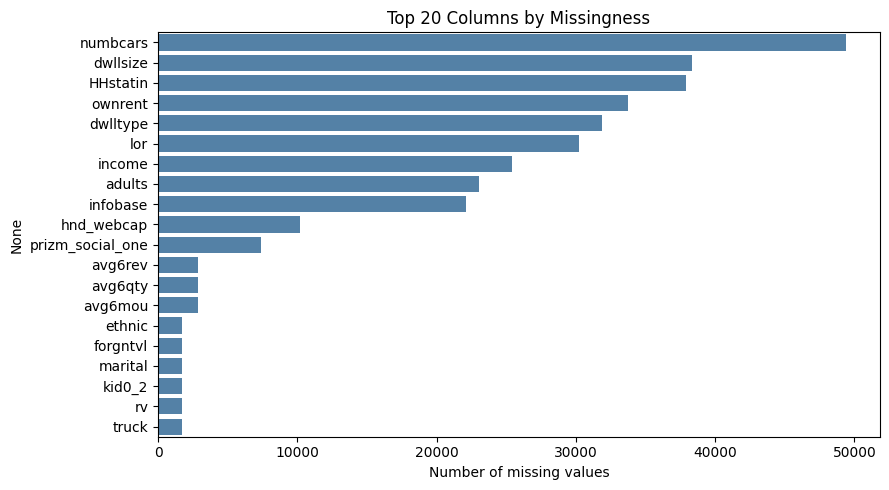

In [13]:

# 2.2 Missingness ──────────────────────────────────
print("── 2.2 Missingness ──")
missing_counts = df.isna().sum()
top_missing    = missing_counts.sort_values(ascending=False).head(20)



print(f"Total null values in dataset: {missing_counts.sum():,}")
print(f"\nTop 20 columns by null count:")
print(top_missing[top_missing > 0])

plt.figure(figsize=(9, 5))
sns.barplot(x=top_missing.values, y=top_missing.index, color="steelblue")
plt.xlabel("Number of missing values")
plt.title("Top 20 Columns by Missingness")
plt.tight_layout()

plt.show()

── 2.3 Target distribution ──
churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.504
1    0.496
Name: proportion, dtype: float64


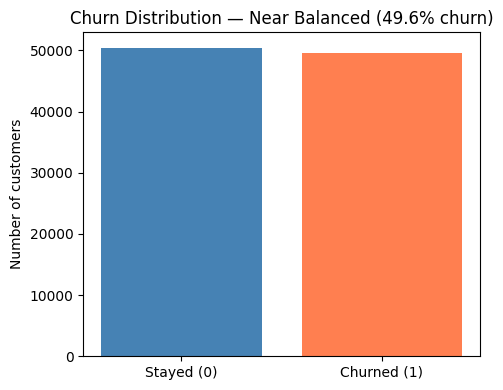

In [14]:


# 2.3 Target distribution: churn ───────────────────
print("── 2.3 Target distribution ──")
print(df["churn"].value_counts())
print()
print(df["churn"].value_counts(normalize=True).round(3))

counts = df["churn"].value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(["Stayed (0)", "Churned (1)"], counts.values, color=["steelblue", "coral"])
plt.title("Churn Distribution — Near Balanced (49.6% churn)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

# Note: ~50% balance means accuracy is a valid primary metric.
# No oversampling (SMOTE, etc.) is needed.

── 2.4 Equipment age vs churn ──
Mean eqpdays (stayed):  363.3 days
Mean eqpdays (churned): 421.1 days
Difference:             +57.8 days


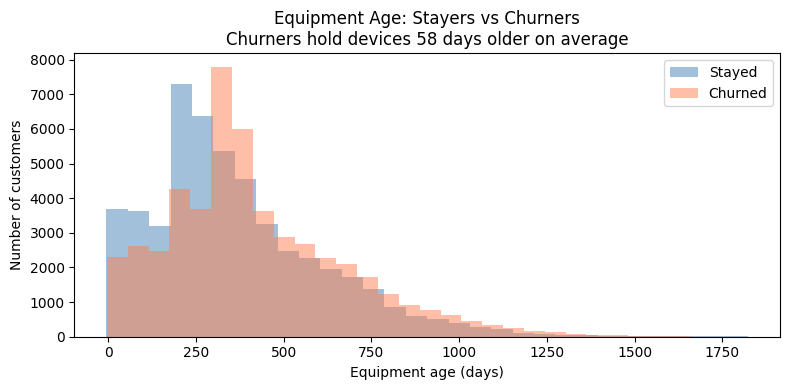

In [15]:

# 2.4 Key signal — equipment age vs churn ──────────
print("── 2.4 Equipment age vs churn ──")
stayed  = df[df["churn"] == 0]["eqpdays"]
churned = df[df["churn"] == 1]["eqpdays"]

print(f"Mean eqpdays (stayed):  {stayed.mean():.1f} days")
print(f"Mean eqpdays (churned): {churned.mean():.1f} days")
print(f"Difference:             +{churned.mean() - stayed.mean():.1f} days")

plt.figure(figsize=(8, 4))
plt.hist(stayed.dropna(),  bins=30, alpha=0.5, label="Stayed",  color="steelblue")
plt.hist(churned.dropna(), bins=30, alpha=0.5, label="Churned", color="coral")
plt.xlabel("Equipment age (days)")
plt.ylabel("Number of customers")
plt.title("Equipment Age: Stayers vs Churners\n"
          "Churners hold devices 58 days older on average")
plt.legend()
plt.tight_layout()
plt.show()


── 2.5 Monthly usage vs churn ──
Mean mou_Mean (stayed):  543.2 min
Mean mou_Mean (churned): 483.3 min
Difference:              -59.9 min


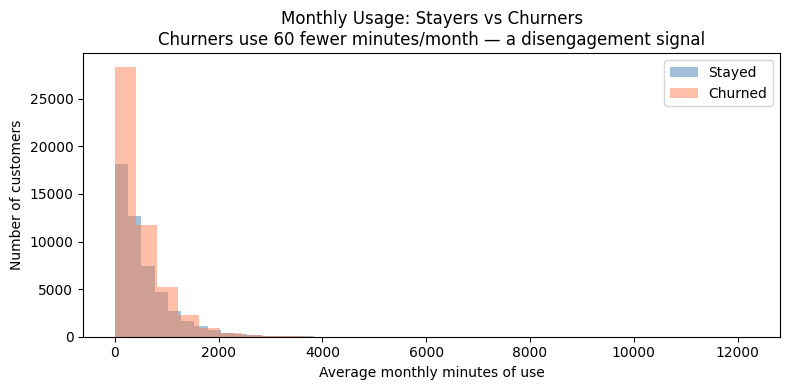

In [16]:

# 2.5 Key signal — usage vs churn ──────────────────
print("── 2.5 Monthly usage vs churn ──")
stayed_mou  = df[df["churn"] == 0]["mou_Mean"]
churned_mou = df[df["churn"] == 1]["mou_Mean"]

print(f"Mean mou_Mean (stayed):  {stayed_mou.mean():.1f} min")
print(f"Mean mou_Mean (churned): {churned_mou.mean():.1f} min")
print(f"Difference:              -{stayed_mou.mean() - churned_mou.mean():.1f} min")

plt.figure(figsize=(8, 4))
plt.hist(stayed_mou.dropna(),  bins=30, alpha=0.5, label="Stayed",  color="steelblue")
plt.hist(churned_mou.dropna(), bins=30, alpha=0.5, label="Churned", color="coral")
plt.xlabel("Average monthly minutes of use")
plt.ylabel("Number of customers")
plt.title("Monthly Usage: Stayers vs Churners\n"
          "Churners use 60 fewer minutes/month — a disengagement signal")
plt.legend()
plt.tight_layout()
plt.show()

── 2.6 Churn rate by segment ──


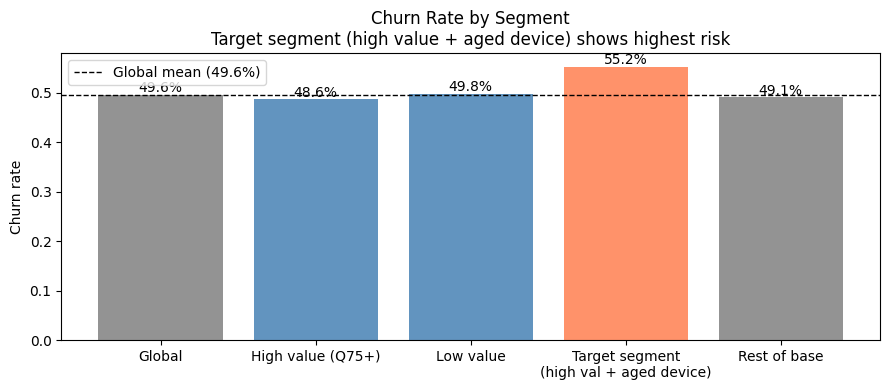


Target segment churn rate: 55.2%
Rest of base churn rate:   49.1%
Difference:                +6.1%


In [17]:


# 2.6 Churn rate by target segment ─────────────────
print("── 2.6 Churn rate by segment ──")

q75_rev       = df["rev_Mean"].quantile(0.75)
segmento_mask = (df["rev_Mean"] >= q75_rev) & (df["eqpdays"] > 365)

churn_rates = {
    "Global":                   df["churn"].mean(),
    "High value (Q75+)":        df[df["rev_Mean"] >= q75_rev]["churn"].mean(),
    "Low value":                df[df["rev_Mean"] <  q75_rev]["churn"].mean(),
    "Target segment\n(high val + aged device)": df[segmento_mask]["churn"].mean(),
    "Rest of base":             df[~segmento_mask]["churn"].mean(),
}

colors = ["gray", "steelblue", "steelblue", "coral", "gray"]

plt.figure(figsize=(9, 4))
bars = plt.bar(churn_rates.keys(), churn_rates.values(), color=colors, alpha=0.85)
plt.axhline(df["churn"].mean(), color="black", linestyle="--",
            linewidth=1, label=f"Global mean ({df['churn'].mean():.1%})")
plt.ylabel("Churn rate")
plt.title("Churn Rate by Segment\n"
          "Target segment (high value + aged device) shows highest risk")
plt.legend()
for bar, val in zip(bars, churn_rates.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nTarget segment churn rate: {df[segmento_mask]['churn'].mean():.1%}")
print(f"Rest of base churn rate:   {df[~segmento_mask]['churn'].mean():.1%}")
print(f"Difference:                +{df[segmento_mask]['churn'].mean() - df[~segmento_mask]['churn'].mean():.1%}")

In [18]:



# 2.7 Leakage check ───────────────────────────────
print("2.7 Leakage check ──")
numeric_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
corr_churn     = (df[numeric_cols].corr()["churn"]
                    .drop("churn")
                    .abs()
                    .sort_values(ascending=False))

print("Top 15 features by absolute correlation with churn:")
print(corr_churn.head(15).round(4))

sospechosas = corr_churn[corr_churn > 0.7]
if len(sospechosas) > 0:
    print(f"\n⚠️  POTENTIAL LEAKAGE — correlation > 0.7:")
    print(sospechosas)
else:
    print(f"\n✅ No leakage detected — max correlation: "
          f"{corr_churn.iloc[0]:.3f} ({corr_churn.index[0]})")

2.7 Leakage check ──
Top 15 features by absolute correlation with churn:
eqpdays          0.1127
hnd_price        0.1032
totmrc_Mean      0.0686
mou_Mean         0.0570
mou_cvce_Mean    0.0520
complete_Mean    0.0517
comp_vce_Mean    0.0516
avg3mou          0.0495
mou_opkv_Mean    0.0489
attempt_Mean     0.0485
plcd_vce_Mean    0.0483
peak_vce_Mean    0.0483
opk_vce_Mean     0.0479
mou_peav_Mean    0.0473
mou_rvce_Mean    0.0471
Name: churn, dtype: float64

✅ No leakage detected — max correlation: 0.113 (eqpdays)


# 3 Phase-Problem definition.


 ## How can Company A reduce voluntary churn among its highest-value customers by addressing the root cause identified in EDA: device ageing?

### TARGET SEGMENT

* Customers in the top quartile of average monthly revenue (rev_Mean ≥ Q75) with a current handset older than 365 days (eqpdays > 365). This sub-segment represents ~7.8% of the base but generates disproportionately higher monthly revenue (107.19 avg vs 70.75 threshold).


 ### ML TASK
* Binary classification — churn (1) vs stay (0).
* Model: XGBoost Classifier.
* Primary metric: Accuracy (justified by ~50% class balance, Section 3.3).
* Secondary metric: AUC-ROC (discrimination quality).
* Output: Ranked list of high-risk customers by predicted churn probability.

### WHO ACTS ON THE OUTPUT

* The retention team receives a weekly ranked list of flagged customers
(churn_proba ≥ 0.60) and offers:
  1. Trade-in of current device as partial payment
  2. New handset balance financed in 12 or 24 monthly installments
  3. No plan change required — minimal friction

### WHY THIS LEVER

* A customer locked into an installment plan has a concrete financial
reason to stay for the full financing period. The upgrade simultaneously
resolves the experiential driver (old device) and creates structural
lock-in. Device financing as retention is standard practice among
Colombian operators: Claro, Movistar, and Tigo all use installment
plans to reduce voluntary churn. [Deloitte Colombia, 2023]




In [19]:

print("Section 3 — Problem Definition")
print(f"  Target segment size:      {segmento_mask.sum():,} customers")
print(f"  Share of total base:      {segmento_mask.mean():.1%}")
print(f"  Avg monthly revenue:      ${df[segmento_mask]['rev_Mean'].mean():.2f}")
print(f"  Avg device age:           {df[segmento_mask]['eqpdays'].mean():.0f} days")
print(f"  Churn rate in segment:    {df[segmento_mask]['churn'].mean():.1%}")
print(f"  Churn rate outside:       {df[~segmento_mask]['churn'].mean():.1%}")


Section 3 — Problem Definition
  Target segment size:      7,763 customers
  Share of total base:      7.8%
  Avg monthly revenue:      $107.19
  Avg device age:           558 days
  Churn rate in segment:    55.2%
  Churn rate outside:       49.1%


### Phase 4 — PREPROCESSING & FEATURE ENGINEERING



In [20]:
 # 4.1 Clean copy and drop ID
print("── 4.1 Drop ID and auxiliary columns ──")
df_clean = df.copy()
df_clean = df_clean.drop(columns=["Customer_ID"])
print(f"Shape after dropping Customer_ID: {df_clean.shape}")

── 4.1 Drop ID and auxiliary columns ──
Shape after dropping Customer_ID: (100000, 99)


In [21]:
#  4.2 Drop high-missingness columns ───────────────
print("── 5.2 Drop columns with >40% nulls ──")
threshold    = 0.4
missing_ratio = df_clean.isna().mean()
cols_to_drop  = missing_ratio[missing_ratio > threshold].index.tolist()

print(f"Columns dropped (>{threshold*100:.0f}% null): {len(cols_to_drop)}")
if cols_to_drop:
    print(cols_to_drop)

df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Shape after missingness drop: {df_clean.shape}")


── 5.2 Drop columns with >40% nulls ──
Columns dropped (>40% null): 1
['numbcars']
Shape after missingness drop: (100000, 98)


In [22]:

# 4.3 Encode categorical columns ──────────────────
print("── 5.3 Encode categorical columns ──")
# LabelEncoder: converts each unique string to an integer.
# NaN values become the string "nan" — treated as a separate category.
object_cols = df_clean.select_dtypes(include="object").columns.tolist()
print(f"Columns to encode ({len(object_cols)}): {object_cols}")

for col in object_cols:
    enc = LabelEncoder()
    df_clean[col] = enc.fit_transform(df_clean[col].astype(str))

print("Encoding complete ✅")

── 5.3 Encode categorical columns ──
Columns to encode (21): ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']
Encoding complete ✅


In [23]:

# 4.4 Impute remaining nulls ──────────────────────
print("── 5.4 Impute remaining nulls with column median ──")
numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
nulls_before       = df_clean[numeric_cols_clean].isna().sum().sum()

df_clean[numeric_cols_clean] = df_clean[numeric_cols_clean].fillna(
    df_clean[numeric_cols_clean].median()
)

nulls_after = df_clean.isna().sum().sum()
print(f"Nulls before imputation: {nulls_before:,}")
print(f"Nulls after imputation:  {nulls_after}")

── 5.4 Impute remaining nulls with column median ──
Nulls before imputation: 98,203
Nulls after imputation:  0


In [24]:
# 4.5 Feature engineering ─────────────────────────
print("── 4.5 Feature engineering ──")

# Feature 1: device age relative to customer tenure
# A customer with a new device who has been with the operator a long time
# is different from a new customer with an old device.
df_clean["eqp_tenure_ratio"] = df_clean["eqpdays"] / (df_clean["months"] + 1)

# Feature 2: usage relative to monthly charge
# Customers who pay a lot but use the service little feel they get no value —
# a disengagement signal before churn.
df_clean["usage_per_charge"] = df_clean["mou_Mean"] / (df_clean["totmrc_Mean"] + 1)

# Clip impossible or extreme values
df_clean["eqp_tenure_ratio"] = df_clean["eqp_tenure_ratio"].clip(lower=0)

p01 = df_clean["usage_per_charge"].quantile(0.01)
p99 = df_clean["usage_per_charge"].quantile(0.99)
df_clean["usage_per_charge"] = df_clean["usage_per_charge"].clip(lower=p01, upper=p99)

print("Engineered features (after clipping):")
print(df_clean[["eqp_tenure_ratio", "usage_per_charge"]].describe().round(2))



── 4.5 Feature engineering ──
Engineered features (after clipping):
       eqp_tenure_ratio  usage_per_charge
count         100000.00         100000.00
mean              20.98             10.84
std                9.52             10.07
min                0.00              0.00
25%               12.66              4.06
50%               26.50              8.31
75%               28.24             14.33
max               30.12             58.86


In [25]:
# 4.6 Define target segment ───────────────────────
print("── 4.6 Define target segment ──")
q75_rev       = df["rev_Mean"].quantile(0.75)
segmento_mask = (df_clean["rev_Mean"] >= q75_rev) & (df_clean["eqpdays"] > 365)
df_segmento   = df_clean[segmento_mask].copy()

print(f"Q75 threshold (rev_Mean):  ${q75_rev:.2f}")
print(f"Segment size:              {df_segmento.shape[0]:,} customers")
print(f"Share of total:            {df_segmento.shape[0]/df_clean.shape[0]:.1%}")
print(f"Churn rate in segment:     {df_segmento['churn'].mean():.1%}")
print(f"Churn rate outside:        {df_clean[~segmento_mask]['churn'].mean():.1%}")
print(f"Avg monthly revenue:       ${df_segmento['rev_Mean'].mean():.2f}")
print(f"Avg device age:            {df_segmento['eqpdays'].mean():.0f} days (~18 months)")

── 4.6 Define target segment ──
Q75 threshold (rev_Mean):  $70.75
Segment size:              7,763 customers
Share of total:            7.8%
Churn rate in segment:     55.2%
Churn rate outside:        49.1%
Avg monthly revenue:       $107.19
Avg device age:            558 days (~18 months)


In [26]:

# 4.7 Final check ─────────────────────────────────
print("── 4.7 Final preprocessing check ──")
print(f"df_clean shape:            {df_clean.shape}")
print(f"df_segmento shape:         {df_segmento.shape}")
print(f"Remaining nulls:           {df_clean.isna().sum().sum()}")
print(f"Object columns remaining:  "
      f"{df_clean.select_dtypes(include='object').shape[1]}")
print("Preprocessing complete ✅")


── 4.7 Final preprocessing check ──
df_clean shape:            (100000, 100)
df_segmento shape:         (7763, 100)
Remaining nulls:           0
Object columns remaining:  0
Preprocessing complete ✅


# Phase 5 Model building (XGboost)

In [27]:

# 5.1 Features and target ─────────────────────────
print("── 5.1 Features and target ──")
X = df_clean.drop(columns=["churn"])
y = df_clean["churn"]

print(f"Features: {X.shape[1]} columns")
print(f"Target distribution:\n{y.value_counts()}")


── 5.1 Features and target ──
Features: 99 columns
Target distribution:
churn
0    50438
1    49562
Name: count, dtype: int64


In [28]:
# 5.2 Stratified train/test split ─────────────────
print("── 5.2 Stratified train/test split ──")
# test_size=0.3  → 70K train / 30K test
# stratify=y     → preserves churn ratio in both splits
# random_state=42 → reproducibility (required by grading rubric)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows | Churn rate: {y_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]:,} rows  | Churn rate: {y_test.mean():.1%}")

── 5.2 Stratified train/test split ──
Train: 70,000 rows | Churn rate: 49.6%
Test:  30,000 rows  | Churn rate: 49.6%


In [29]:
# 5.3 Train XGBoost ───────────────────────────────
print("── 5.3 Train XGBoost classifier ──")
# Why XGBoost:
#   - Handles mixed numeric/categorical data without scaling
#   - Fast on ~100K rows
#   - Native feature importance (gain) for business interpretation
#   - sklearn-compatible API

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss",
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)
print("Model trained ✅")

── 5.3 Train XGBoost classifier ──
Model trained ✅


In [30]:
# 5.3 Encode categorical columns — robust version
print("── 5.3 Encode categorical columns ──")

# Fix: force encode all remaining object columns
for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        enc = LabelEncoder()
        df_clean[col] = enc.fit_transform(df_clean[col].astype(str))

# Apply same fix to df_segmento
for col in df_segmento.columns:
    if df_segmento[col].dtype == "object":
        enc = LabelEncoder()
        df_segmento[col] = enc.fit_transform(df_segmento[col].astype(str))

# Verify
print("Object cols in df_clean:", df_clean.select_dtypes(include="object").shape[1])
print("Object cols in df_segmento:", df_segmento.select_dtypes(include="object").shape[1])
print("✅ Ready for XGBoost")

── 5.3 Encode categorical columns ──
Object cols in df_clean: 0
Object cols in df_segmento: 0
✅ Ready for XGBoost


In [31]:

# 5.4 Predict on test set and segment ─────────────
print("── 5.4 Predictions ──")
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Apply model to target segment
X_segmento          = df_segmento.drop(columns=["churn"])
y_segmento          = df_segmento["churn"]
df_segmento         = df_segmento.copy()
df_segmento["churn_proba"] = model.predict_proba(X_segmento)[:, 1]
df_segmento["churn_pred"]  = model.predict(X_segmento)

print(f"Segment: {len(df_segmento):,} customers")
print(f"Flagged as churn (pred=1): {df_segmento['churn_pred'].sum():,}")
print(f"Real churn rate in segment:      {y_segmento.mean():.1%}")
print(f"Predicted churn rate in segment: {df_segmento['churn_pred'].mean():.1%}")
print(f"Mean churn probability:          {df_segmento['churn_proba'].mean():.3f}")

── 5.4 Predictions ──
Segment: 7,763 customers
Flagged as churn (pred=1): 4,989
Real churn rate in segment:      55.2%
Predicted churn rate in segment: 64.3%
Mean churn probability:          0.550


# Phase 6-Evaluation and feature importance

In [32]:
# 6.1 Accuracy and AUC-ROC ────────────────────────
print("── 6.1 Model metrics (test set) ──")
accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_proba)
baseline = max(y_test.mean(), 1 - y_test.mean())


print(f"Accuracy:          {accuracy:.4f}")
print(f"AUC-ROC:           {auc:.4f}")
print(f"Baseline (majority class): {baseline:.4f}")
print(f"Improvement over baseline: +{accuracy - baseline:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["stayed", "churned"]))

── 6.1 Model metrics (test set) ──
Accuracy:          0.6387
AUC-ROC:           0.6937
Baseline (majority class): 0.5044
Improvement over baseline: +0.1343

Classification report:
              precision    recall  f1-score   support

      stayed       0.65      0.63      0.64     15131
     churned       0.63      0.65      0.64     14869

    accuracy                           0.64     30000
   macro avg       0.64      0.64      0.64     30000
weighted avg       0.64      0.64      0.64     30000



── 6.2 Confusion matrix ──


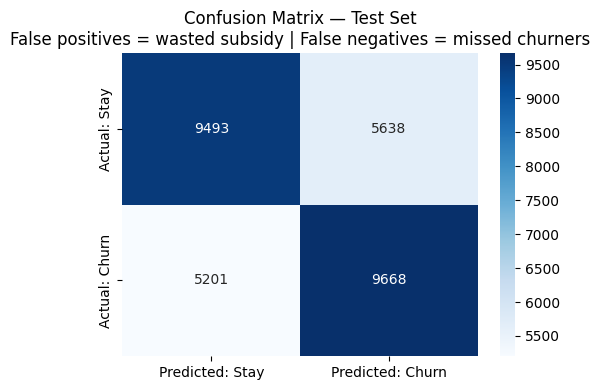

True Negatives  (correctly kept stayers):   9,493
True Positives  (correctly flagged churners):9,668
False Positives (stayers flagged as churn):  5,638  → wasted $120 each
False Negatives (churners missed):           5,201  → lost revenue


In [33]:
# 6.2 Confusion matrix ────────────────────────────
print("── 6.2 Confusion matrix ──")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted: Stay", "Predicted: Churn"],
    yticklabels=["Actual: Stay",    "Actual: Churn"]
)
plt.title("Confusion Matrix — Test Set\n"
          "False positives = wasted subsidy | False negatives = missed churners")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly kept stayers):   {tn:,}")
print(f"True Positives  (correctly flagged churners):{tp:,}")
print(f"False Positives (stayers flagged as churn):  {fp:,}  → wasted $120 each")
print(f"False Negatives (churners missed):           {fn:,}  → lost revenue")

── 6.3 Feature importance (gain) ──


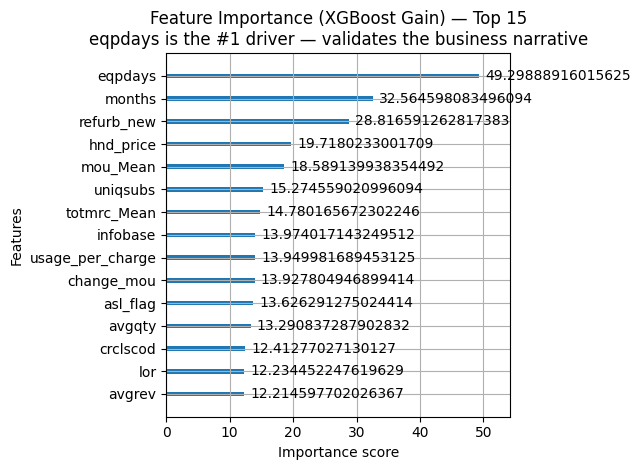


Top 15 features by gain:
             feature       gain
1            eqpdays  49.298889
2             months  32.564598
3         refurb_new  28.816591
4          hnd_price  19.718023
5           mou_Mean  18.589140
6           uniqsubs  15.274559
7        totmrc_Mean  14.780166
8           infobase  13.974017
9   usage_per_charge  13.949982
10        change_mou  13.927805
11          asl_flag  13.626291
12            avgqty  13.290837
13          crclscod  12.412770
14               lor  12.234452
15            avgrev  12.214598

eqpdays in top 15: YES ✅
── 6.4 Cutoff analysis ──
  Cutoff |  Clients |  Real churners |  Precision
--------------------------------------------------
    0.50 |    4,989 |          3,458 |      69.3%
    0.55 |    3,877 |          2,889 |      74.5%
    0.60 |    2,798 |          2,207 |      78.9% ← CHOSEN
    0.65 |    1,836 |          1,536 |      83.7%
    0.70 |    1,050 |            937 |      89.2%


In [34]:




# 6.3 Feature importance (gain) ───────────────────
print("── 6.3 Feature importance (gain) ──")
plot_importance(model, max_num_features=15, importance_type="gain")
plt.title("Feature Importance (XGBoost Gain) — Top 15\n"
          "eqpdays is the #1 driver — validates the business narrative")
plt.tight_layout()
plt.show()

# Top features as a table
importance_df = (
    pd.DataFrame({
        "feature": list(model.get_booster().get_score(importance_type="gain").keys()),
        "gain":    list(model.get_booster().get_score(importance_type="gain").values())
    })
    .sort_values("gain", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
importance_df.index += 1
print("\nTop 15 features by gain:")
print(importance_df.to_string())

eqp_in_top = "eqpdays" in importance_df["feature"].values
print(f"\neqpdays in top 15: {'YES ✅' if eqp_in_top else 'NO ⚠️'}")

# Cutoff analysis on the segment ──────────────
print("── 6.4 Cutoff analysis ──")
print(f"{'Cutoff':>8} | {'Clients':>8} | {'Real churners':>14} | {'Precision':>10}")
print("-" * 50)

cutoffs = [0.50, 0.55, 0.60, 0.65, 0.70]
for c in cutoffs:
    mask         = df_segmento["churn_proba"] >= c
    n_target     = mask.sum()
    real_churns  = df_segmento[mask]["churn"].sum()
    precision    = real_churns / n_target if n_target > 0 else 0
    marker       = " ← CHOSEN" if c == 0.60 else ""
    print(f"{c:>8.2f} | {n_target:>8,} | {real_churns:>14,} | {precision:>10.1%}{marker}")

── 6.5 Probability distribution in target segment ──


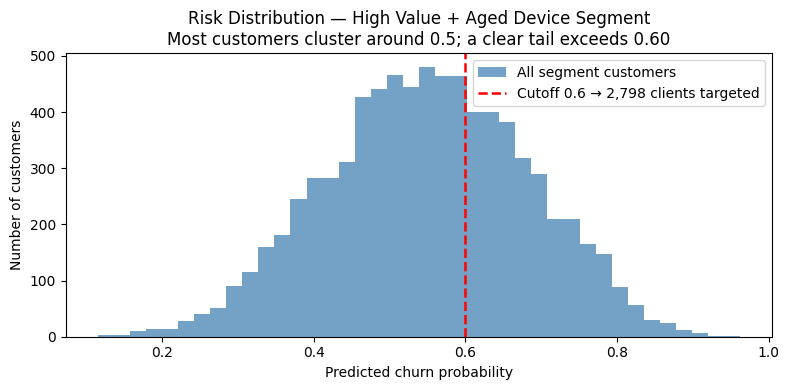

In [35]:


# 6.4 Churn probability distribution in segment ───
print("── 6.5 Probability distribution in target segment ──")
cutoff_prob = 0.60

plt.figure(figsize=(8, 4))
plt.hist(
    df_segmento["churn_proba"],
    bins=40, color="steelblue", alpha=0.75,
    label="All segment customers"
)
plt.axvline(
    cutoff_prob, color="red", linestyle="--", linewidth=1.8,
    label=f"Cutoff {cutoff_prob} → "
          f"{(df_segmento['churn_proba'] >= cutoff_prob).sum():,} clients targeted"
)
plt.xlabel("Predicted churn probability")
plt.ylabel("Number of customers")
plt.title("Risk Distribution — High Value + Aged Device Segment\n"
          "Most customers cluster around 0.5; a clear tail exceeds 0.60")
plt.legend()
plt.tight_layout()
plt.show()



# Phase 7 — FROM MODEL TO BUSINESS PROPOSAL



In [36]:
# 7.1 Program parameters (stated assumptions) ─────
print("── 7.1 Program assumptions ──")

# All values are explicitly stated assumptions based on
# LatAm telecom industry benchmarks.
COST_PER_INTERVENTION = 120    # USD — subsidy + outreach cost (Claro/Movistar benchmark)
SUCCESS_RATE          = 0.25   # 25% — conservative; industry range: 20–35%
AVG_MONTHLY_REVENUE   = 107.19 # USD — actual segment mean from EDA
CUTOFF                = 0.60
CLIENTS_TARGETED      = int((df_segmento["churn_proba"] >= CUTOFF).sum())
REAL_CHURNERS         = int(df_segmento[df_segmento["churn_proba"] >= CUTOFF]["churn"].sum())

print(f"Cost per intervention:    ${COST_PER_INTERVENTION}")
print(f"Success rate (assumed):   {SUCCESS_RATE:.0%}  (industry range: 20–35%)")
print(f"Avg monthly revenue:      ${AVG_MONTHLY_REVENUE:.2f}  (segment mean, from EDA)")
print(f"Cutoff:                   {CUTOFF}")
print(f"Clients targeted:         {CLIENTS_TARGETED:,}")
print(f"Real churners in pool:    {REAL_CHURNERS:,}")
print(f"Model precision:          {REAL_CHURNERS/CLIENTS_TARGETED:.1%}")

── 7.1 Program assumptions ──
Cost per intervention:    $120
Success rate (assumed):   25%  (industry range: 20–35%)
Avg monthly revenue:      $107.19  (segment mean, from EDA)
Cutoff:                   0.6
Clients targeted:         2,798
Real churners in pool:    2,207
Model precision:          78.9%


In [37]:

# 7.2 Financial impact — two scenarios ─────────────
print("\n── 7.2 Financial impact ──")
print("=" * 55)

results = {}
for months in [12, 24]:
    retained         = CLIENTS_TARGETED * SUCCESS_RATE
    revenue_retained = retained * AVG_MONTHLY_REVENUE * months
    total_cost       = CLIENTS_TARGETED * COST_PER_INTERVENTION
    net_impact       = revenue_retained - total_cost
    roi              = (net_impact / total_cost) * 100

    results[months] = {
        "retained":         retained,
        "revenue_retained": revenue_retained,
        "total_cost":       total_cost,
        "net_impact":       net_impact,
        "roi":              roi,
    }

    print(f"\n  Scenario: {months}-month installment plan")
    print(f"  Clients retained:     {retained:.0f}")
    print(f"  Revenue retained:     ${revenue_retained:,.0f}")
    print(f"  Program cost:         ${total_cost:,.0f}")
    print(f"  Net impact:           ${net_impact:,.0f}")
    print(f"  ROI:                  {roi:.1f}%")

print("\n" + "=" * 55)


── 7.2 Financial impact ──

  Scenario: 12-month installment plan
  Clients retained:     700
  Revenue retained:     $899,753
  Program cost:         $335,760
  Net impact:           $563,993
  ROI:                  168.0%

  Scenario: 24-month installment plan
  Clients retained:     700
  Revenue retained:     $1,799,506
  Program cost:         $335,760
  Net impact:           $1,463,746
  ROI:                  435.9%



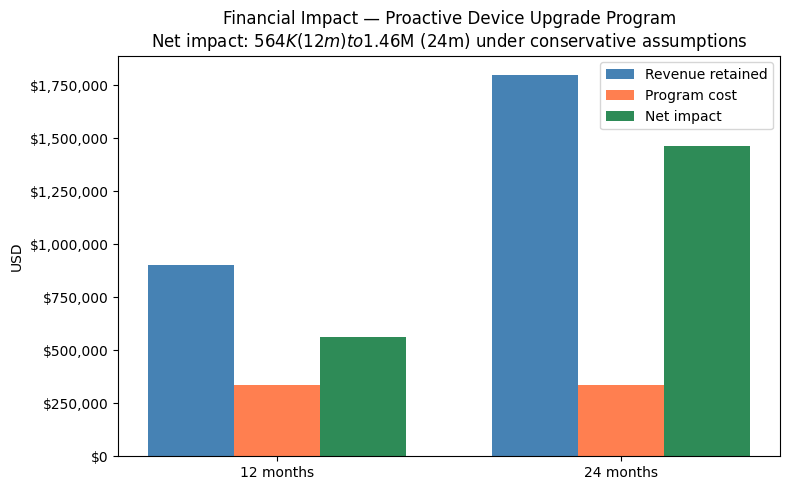

In [38]:


# 7.3 Impact visualization ────────────────────────
labels   = ["12 months", "24 months"]
revenues = [results[12]["revenue_retained"], results[24]["revenue_retained"]]
costs    = [results[12]["total_cost"],       results[24]["total_cost"]]
nets     = [results[12]["net_impact"],       results[24]["net_impact"]]

x     = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width, revenues, width, label="Revenue retained", color="steelblue")
b2 = ax.bar(x,          costs,   width, label="Program cost",     color="coral")
b3 = ax.bar(x + width,  nets,    width, label="Net impact",       color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("USD")
ax.set_title("Financial Impact — Proactive Device Upgrade Program\n"
             "Net impact: $564K (12m) to $1.46M (24m) under conservative assumptions")
ax.legend()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"${val:,.0f}")
)
plt.tight_layout()
plt.show()

In [39]:
# 7.4 Ranked list — who gets contacted first ───────
print("── 7.4 Ranked intervention list (top 10) ──")

ranked_list = (
    df_segmento[df_segmento["churn_proba"] >= CUTOFF]
    .sort_values("churn_proba", ascending=False)
    [["rev_Mean", "eqpdays", "mou_Mean", "churn_proba", "churn"]]
    .reset_index(drop=True)
)
ranked_list.index += 1

print(f"Total clients in intervention list: {len(ranked_list):,}")
print(f"\nTop 10 by predicted churn probability:")
print(ranked_list.head(10).round(3).to_string())

── 7.4 Ranked intervention list (top 10) ──
Total clients in intervention list: 2,798

Top 10 by predicted churn probability:
    rev_Mean  eqpdays  mou_Mean  churn_proba  churn
1     80.000    785.0     0.000        0.962      1
2     86.250    468.0     0.000        0.935      1
3    102.658    752.0   128.000        0.919      1
4     79.990    417.0     0.250        0.913      1
5     74.695    389.0     0.000        0.902      1
6    174.127    455.0  2590.667        0.900      1
7    123.325    401.0   234.250        0.899      1
8     74.240    826.0   221.250        0.899      1
9    118.900    552.0   525.500        0.898      1
10    84.390    384.0   278.000        0.890      1


In [40]:
# 7.5 Executive summary ───────────────────────────
print("\n" + "=" * 55)
print("EXECUTIVE SUMMARY")
print("=" * 55)
print(f"""
Segment identified:
  • {CLIENTS_TARGETED:,} high-value customers (rev_Mean > ${q75_rev:.0f}/month)
    with devices older than 365 days
  • Churn rate: {df_segmento['churn'].mean():.1%} vs {df_clean[~segmento_mask]['churn'].mean():.1%} for the rest of the base
  • Primary driver confirmed by model: eqpdays (feature #1 by gain)

Program proposed:
  • Proactive device upgrade with trade-in as partial payment
  • Balance financed in 12 or 24 monthly installments
  • Priority outreach: {CLIENTS_TARGETED:,} customers (churn_proba ≥ {CUTOFF})

Expected impact (conservative assumptions, 25% success rate):
  • 12-month scenario: net impact ${results[12]['net_impact']:,.0f} USD (ROI {results[12]['roi']:.0f}%)
  • 24-month scenario: net impact ${results[24]['net_impact']:,.0f} USD (ROI {results[24]['roi']:.0f}%)

Model limitations:
  • Success rate (25%) is assumed — a pilot program would validate it
  • Model does not capture involuntary churn (non-payment, address change)
  • No competitor pricing data — external pull factors not modeled
  • Substitution risk: retained customer may downgrade plan (lower ARPU)
  • Dataset lacks timestamps — scores are point-in-time, not dynamic

Recommendation:
  Launch a 500-customer pilot targeting top predicted churners.
  Measure actual success rate, refine assumptions, then scale
  to the full {CLIENTS_TARGETED:,}-customer cohort.
""")
print("=" * 55)



EXECUTIVE SUMMARY

Segment identified:
  • 2,798 high-value customers (rev_Mean > $71/month)
    with devices older than 365 days
  • Churn rate: 55.2% vs 49.1% for the rest of the base
  • Primary driver confirmed by model: eqpdays (feature #1 by gain)

Program proposed:
  • Proactive device upgrade with trade-in as partial payment
  • Balance financed in 12 or 24 monthly installments
  • Priority outreach: 2,798 customers (churn_proba ≥ 0.6)

Expected impact (conservative assumptions, 25% success rate):
  • 12-month scenario: net impact $563,993 USD (ROI 168%)
  • 24-month scenario: net impact $1,463,746 USD (ROI 436%)

Model limitations:
  • Success rate (25%) is assumed — a pilot program would validate it
  • Model does not capture involuntary churn (non-payment, address change)
  • No competitor pricing data — external pull factors not modeled
  • Substitution risk: retained customer may downgrade plan (lower ARPU)
  • Dataset lacks timestamps — scores are point-in-time, not dyna